# Рабочая тетрадь по ПСИИ №4

## Студента группы БФБО-06-24 Петрова Артема

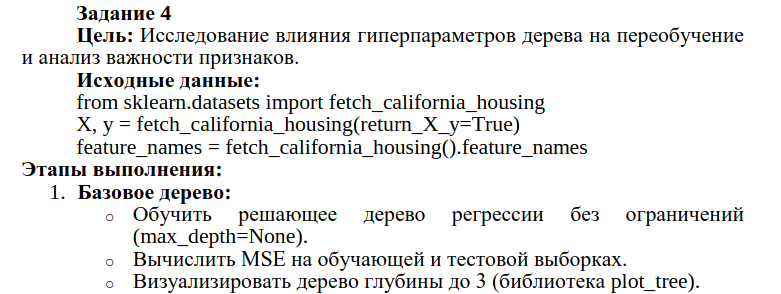

MSE_Train: 7.873576987705089e-32;
MSE_Test: 0.5356969916161983.


[Text(0.5, 0.9, 'MedInc <= 5.03\nsquared_error = 1.34\nsamples = 14448\nvalue = 2.07'),
 Text(0.25, 0.7, 'MedInc <= 3.07\nsquared_error = 0.83\nsamples = 11340\nvalue = 1.73'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'AveRooms <= 4.2\nsquared_error = 0.56\nsamples = 5490\nvalue = 1.36'),
 Text(0.0625, 0.3, 'AveOccup <= 2.44\nsquared_error = 0.7\nsamples = 2018\nvalue = 1.66'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'MedInc <= 2.4\nsquared_error = 0.4\nsamples = 3472\nvalue = 1.18'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'AveOccup <= 2.35\nsquared_error = 0.83\nsamples = 5850\nvalue = 2.08'),
 Text(0.3125, 0.3, 'HouseAge <= 24.5\nsquared_error = 1.3\nsamples = 1270\nvalue = 2.82'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'MedInc <= 4.12\nsquared_error = 0.51\nsamples = 4580\nvalue = 1.88'),
 Text(0.40625, 0.1, '\n  

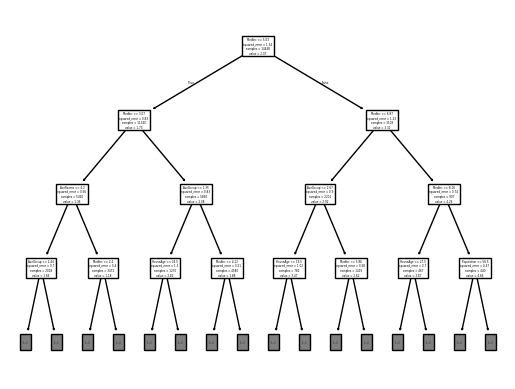

In [2]:
from sklearn.datasets import fetch_california_housing
X, y = fetch_california_housing(return_X_y=True)
feature_names = fetch_california_housing().feature_names

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import plot_tree

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

regr_tree = DecisionTreeRegressor(max_depth = None)
regr_tree.fit(X_train, y_train)
y_pred = regr_tree.predict(X_test)
y_pred_train = regr_tree.predict(X_train)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred)
print(f'MSE_Train: {mse_train};\nMSE_Test: {mse_test}.')

plot_tree(decision_tree = regr_tree, feature_names = feature_names, precision = 2, max_depth = 3)

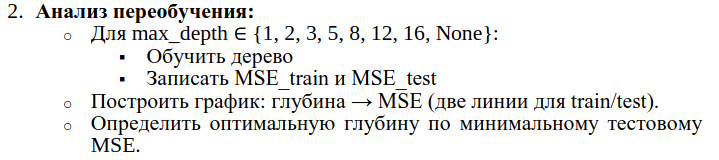

Минимальный тестовый MSE = 0.4234149783997606;
Оптимальная глубина = 8.


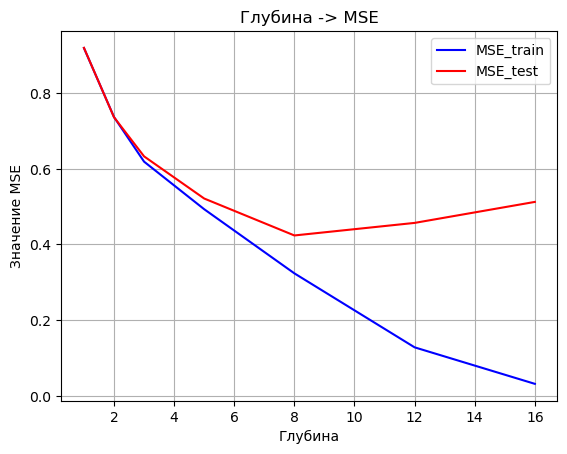

In [3]:
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 8, 12, 16, None]
MSE_train, MSE_test = [], []
MSE_min = 1

for i in range(len(depths)):
    regr_tree = DecisionTreeRegressor(max_depth = depths[i])
    regr_tree.fit(X_train, y_train)
    
    y_pred_train = regr_tree.predict(X_train)
    y_pred_test = regr_tree.predict(X_test)
    
    MSE_train.append(mean_squared_error(y_train, y_pred_train))
    MSE_test.append(mean_squared_error(y_test, y_pred_test))

    if MSE_min > MSE_test[i]:
        MSE_min = MSE_test[i]
        opt_depth_id = i

print(f'Минимальный тестовый MSE = {MSE_min};\nОптимальная глубина = {depths[opt_depth_id]}.')

plt.plot(depths, MSE_train, color = 'blue', label = 'MSE_train')
plt.plot(depths, MSE_test, color = 'red', label = 'MSE_test')
plt.title('Глубина -> MSE')
plt.xlabel('Глубина')
plt.ylabel('Значение MSE')
plt.legend()
plt.grid()
plt.show()

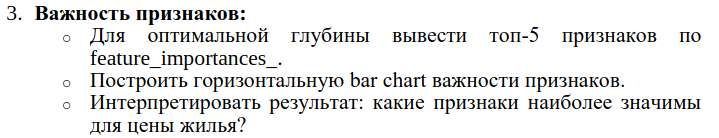

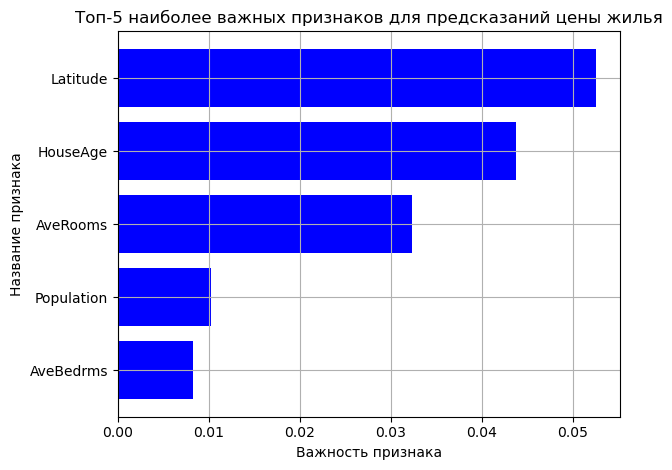

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Так как модель не сохранилась, обучим её ещё раз использую оптимальную глубину
opt_reg_tree = DecisionTreeRegressor(max_depth = depths[opt_depth_id])
opt_reg_tree.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': opt_reg_tree.feature_importances_
})

feature_importance = feature_importance.sort_values('importance')

top_5_features = feature_importance.head(5)

plt.barh(top_5_features['feature'], top_5_features['importance'], color = 'blue')
plt.title('Топ-5 наиболее важных признаков для предсказаний цены жилья')
plt.xlabel('Важность признака')
plt.ylabel('Название признака')
plt.grid()
plt.tight_layout()
plt.show()

Наиболее значимые признаки для предсказания цены жилья - Latitude(Площадь), HouseAge(Возраст дома), AveRooms(количество комнат).

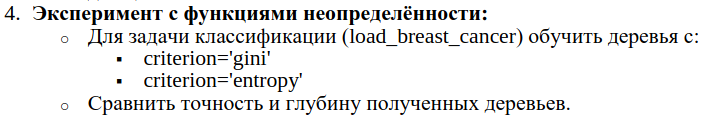

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_namesdata = load_breast_cancer()

X_train, X_test, y_traim, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

tree_gini = DecisionTreeClassifier(criterion = 'gini', random_state = 42, max_depth = None)
tre_entropy = DecisionTreeClassifier(criterion = 'entropy', random_state = 42, max_depth = None)

tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)

pred_y_train_gini = tree_gini.predict(X_train)
pred_y_test_gini = tree_gini.predict(X_test)
pred_y_train_entropy = tree_entropy.predict(X_train)
pred_y_test_entropy = tree_entropy.predict(X_test)

acc_train_gini = accuracy_score(y_train, pred_y_train_gini)
acc_test_gini = accuracy_score(y_test, pred_y_test_gini)
acc_train_entropy = accuracy_score(y_train, pred_y_train_entropy)
acc_test_entropy = accuracy_score(y_test, pred_y_test_entropy)

depth_gini = tree_gini.get_depth()
depth_entropy = tree_entropy.get_depth()

print(f'Gini Criterion:\nTest_Accuracy: {acc_test_gini};\nTrain_Accuracy: {acc_train_gini};\nГлубина Дерева: {depth_gini}.\n')
print(f'Entropy criterion:\nTest_Accuracy: {acc_test_entropy};\nTrain_Accutacy: {acc_train_entropy};\nГлубина Дерева: {depth_entropy}.')

Gini Criterion:
Test_Accuracy: 0.9181286549707602;
Train_Accuracy: 1.0;
Глубина Дерева: 6.

Entropy criterion:
Test_Accuracy: 0.9473684210526315;
Train_Accutacy: 1.0;
Глубина Дерева: 7.


Дерево обученное с критерием Энтропии оказалось точнее на 0.03 и глубже на 1 уровень, чем дерево обученное с критерием Джини.

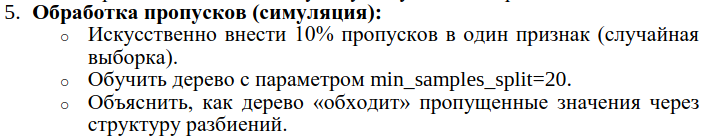

In [13]:
X, y = fetch_california_housing(return_X_y=True)
feature_names = fetch_california_housing().feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

np.random.seed(42)  # для воспроизводимости
random_feature = np.random.choice(feature_names)
print(f"Для внесения пропусков выбран признак: {random_feature}")

# Выбираем 10% от всех строк и сохраняем индексы
n_samples = len(X_train_df)
n_missing = int(0.1 * n_samples)  
missing_indices = np.random.choice(n_samples, size=n_missing, replace=False)

# Заменяем значения на пропуски (NaN)
X_train_df.loc[missing_indices, random_feature] = np.nan

# Теперь обучим дерево с параметром min_saples_split=20
tree_nan = DecisionTreeRegressor(min_samples_split = 20, random_state = 42)

# К сожалению, sklearn не умеет работать с NaN значениями
# Поэтому используем более продвинутую билбиотеку - XGBoost

Для внесения пропусков выбран признак: Latitude


In [31]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 28.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 26.5 MB/s eta 0:00:00m eta 0:00:010:00:01
Note: you may need to restart the kernel to use updated packages.


In [19]:
# Создаем копию данных с пропусками
X_train_nan = X_train.copy()
X_test_nan = X_test.copy()

# Преобразуем в DataFrame для удобства
X_train_nan_df = pd.DataFrame(X_train_nan, columns=feature_names)

# Вносим 10% пропусков
np.random.seed(42)
random_feature_idx = np.random.randint(0, len(feature_names))
random_feature = feature_names[random_feature_idx]

n_samples = len(X_train_nan_df)
n_missing = int(0.1 * n_samples)
missing_indices = np.random.choice(n_samples, size=n_missing, replace=False)

# В XGBoost пропуски обозначаются как NaN
X_train_nan_df.loc[missing_indices, random_feature] = np.nan
print(f"Внесено {n_missing} пропусков в признак '{random_feature}'")

# СОЗДАЕМ XGBOOST МОДЕЛЬ, которая будет работать с пропусками
model_xgb_with_nans = xgb.XGBRegressor(
    max_depth=8,
    n_estimators=1,
    random_state=42,
    objective='reg:squarederror',
    missing=np.nan,           # Явно указываем, что NaN - это пропуски
    tree_method='auto'         # Автоматический выбор метода
)

# Обучаем НА ДАННЫХ С ПРОПУСКАМИ! (XGBoost не падает)
model_xgb_with_nans.fit(X_train_nan_df, y_train)

# Делаем предсказания
y_train_pred_nan = model_xgb_with_nans.predict(X_train_nan_df)
y_test_pred_nan = model_xgb_with_nans.predict(pd.DataFrame(X_test, columns=feature_names))

# Оцениваем качество
mse_train_nan = mean_squared_error(y_train, y_train_pred_nan)
mse_test_nan = mean_squared_error(y_test, y_test_pred_nan)

print(f"\nРезультаты модели с пропусками (XGBoost):")
print(f"MSE Train: {mse_train_nan:.4f}")
print(f"MSE Test: {mse_test_nan:.4f}")

# Для сравнения обучим на данных без пропусков
model_clean = xgb.XGBRegressor(
    max_depth=8,
    n_estimators=1,
    random_state=42,
    objective='reg:squarederror'
)
model_clean.fit(X_train, y_train)
mse_test_clean = mean_squared_error(y_test, model_clean.predict(X_test))

print(f"\nСравнение версий:")
print(f"MSE Test (без пропусков): {mse_test_clean:.4f}")
print(f"MSE Test (с 10% пропусков): {mse_test_nan:.4f}")
print(f"Разница: {abs(mse_test_clean - mse_test_nan):.4f}")

Внесено 1444 пропусков в признак 'Latitude'

Результаты модели с пропусками (XGBoost):
MSE Train: 0.8377
MSE Test: 0.8511

Сравнение версий:
MSE Test (без пропусков): 0.8511
MSE Test (с 10% пропусков): 0.8511
Разница: 0.0000


Модель из библиотеки XGBoost использует специальный алгоритм, который учитывает разреженность данных. Для каждого признака алгоритм определяет оптимальное направление для объектов с пропущенными значениями. При поиске оптимального разбиения учитываются только объекты с известными значениями признака. После выбора порога разбиения, для объектов с пропуском определяется, в какую сторону (левую или правую) их напрвлять, чтобы минимизировать ф-цию потерь. Напраправление может быть разнам для разных узлов дерева.

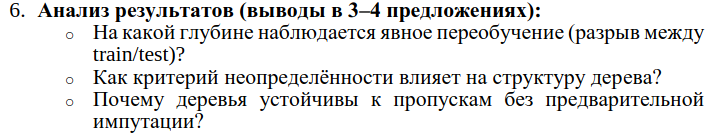

## На какой глубине наблюдается явное переобучение (разрыв между train/test)?

Переобучение начинается с глубины 10 и дальше, появляется расхождение.

## Как критерий неопределённости влияет на структуру дерева?

Критерий влияет на выбор разбиений, но разница не сильно большая, в пользу "entropy". Но "entropy" представляет собой более сложные вычисления, чем "gini", от чего скорость обучения падает.

## Почему деревья устойчивы к пропускам без предварительной импутации?

Деревья устойчивы к пропускам, потому что они могут перенаправлять объекты в ветку минимизирующую ошибку, используя информацию из других признаков.